**Problem No**: 04

**Problem Statement**: Take an image and plot the histogram of the array with proper labels (without built in histogram function), match another image. Show both the image and the equalized histogram with a title.

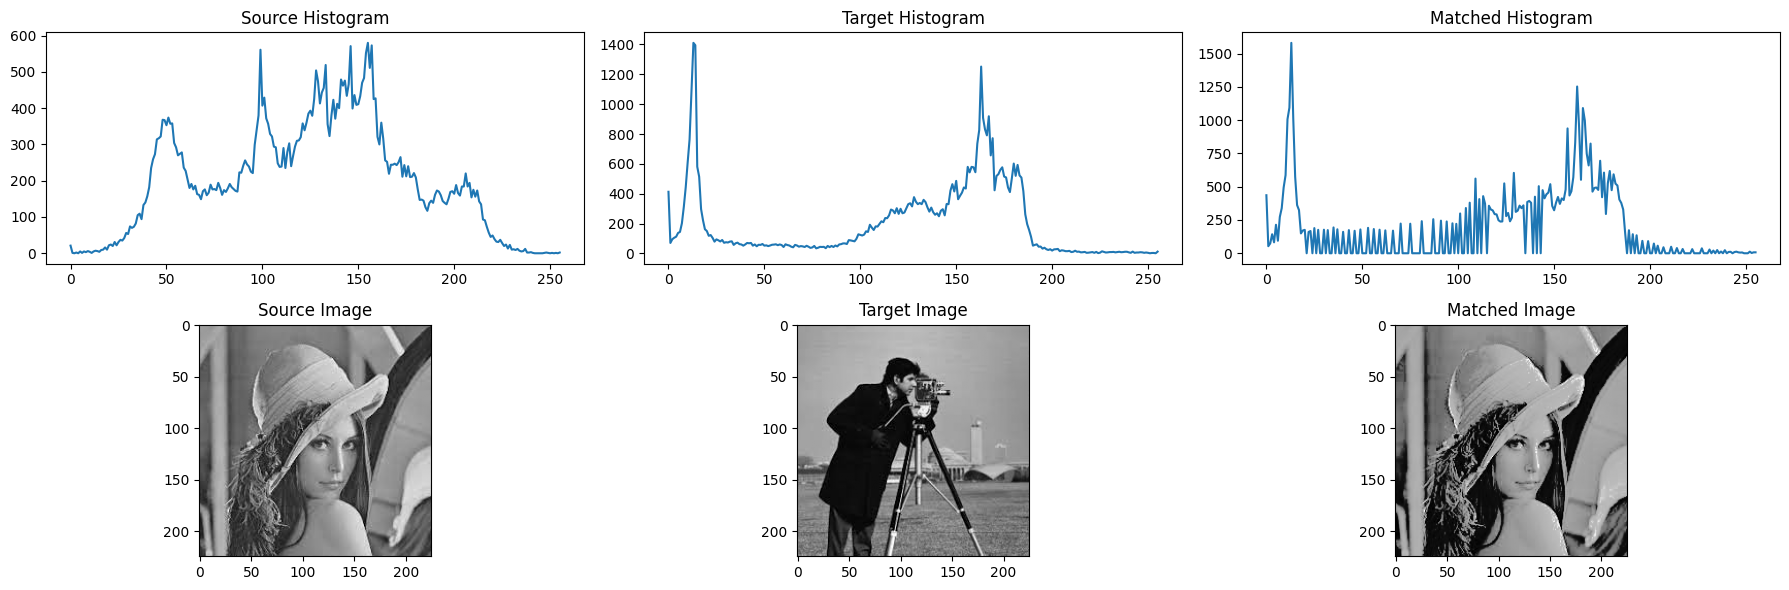

In [3]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load images (grayscale)
src = cv2.imread("./a.jpg", 0)
target = cv2.imread("./ref_image.jpg", 0)   # Target image

def compute_hist_pdf_cdf(image):
    hist = np.zeros(256)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            hist[image[i, j]] += 1

    num_pixels = image.shape[0] * image.shape[1]
    pdf = hist / num_pixels

    cdf = np.zeros(256)
    cdf[0] = pdf[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + pdf[i]

    return hist, pdf, cdf

# Source stats
hist_s, pdf_s, cdf_s = compute_hist_pdf_cdf(src)

# Target stats
hist_t, pdf_t, cdf_t = compute_hist_pdf_cdf(target)

mapping = np.zeros(256, dtype=np.uint8)

for i in range(256):
    diff = np.abs(cdf_s[i] - cdf_t)
    mapping[i] = np.argmin(diff)

matched = np.zeros_like(src)

for i in range(src.shape[0]):
    for j in range(src.shape[1]):
        matched[i, j] = mapping[src[i, j]]

# Histogram of matched image
hist_m, _, _ = compute_hist_pdf_cdf(matched)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

plt.figure(figsize=(18,6))

plt.subplot(2,3,1)
plt.title("Source Histogram")
plt.plot(hist_s)

plt.subplot(2,3,2)
plt.title("Target Histogram")
plt.plot(hist_t)

plt.subplot(2,3,3)
plt.title("Matched Histogram")
plt.plot(hist_m)

plt.subplot(2,3,4)
plt.title("Source Image")
plt.imshow(src, cmap='gray')

plt.subplot(2,3,5)
plt.title("Target Image")
plt.imshow(target, cmap='gray')

plt.subplot(2,3,6)
plt.title("Matched Image")
plt.imshow(matched, cmap='gray')

plt.tight_layout()
plt.show()